<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/260921_%EC%B6%94%EC%B2%9C%EC%8B%9C%EC%8A%A4%ED%85%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 추천 시스템(Recommendations)
## 추천 시스템의 개요와 배경
### 추천 시스템의 개요


*   하나의 콘텐츠를 선택했을 때 선택된 콘텐츠와 연관된 추천 콘텐츠가 얼마나 사용자의 관심을 끌고 개인에게 맞춘 콘텐츠를 추천했는지는 그 사이트의 평판을 좌우하는 매우 중요한 요소임. 추천 시스템의 진정한 묘미는 사용자 자신도 좋아하는지 몰랐던 취향을 발견하고 그에 맞는 콘텐츠를 추천해주는 것임. 이러한 추천 시스템을 접한 사용자는 해당 사이트를 더 강하게 신뢰하게 되어 더 많은 추천 콘텐츠를 선택하게 됨. 결국 더 많은 데이터가 추천 시스템에 축적되면서 추천이 더욱 정확해지고 다양한 결과를 얻을 수 있는 좋은 선순환 시스템을 구축할 수 있게 됨.

### 온라인 스토어의 필수 요소
*   한정된 시간이라는 제약을 가진 상황에서 너무 많은 상품과 콘텐츠는 오히려 사용자가 어떤 상품을 골라야 할지에 대한 압박감을 느끼게 만들 수밖에 없는데, 추천 시스템이 이러한 상황을 타개해줌. 좋은 추천 시스템은 사용자가 무엇을 원하는지 빠르게 찾아내 사용자의 온라인 쇼핑의 즐거움을 배가함.



### 추천 시스템의 유형

*   추천 시스템은 크게 **콘텐츠 기반 필터링(Content based filtering) 방식**과 **협업 필터링(Collaborative Filtering) 방식**으로 나뉨. 그리고 **협업 필터링 방식은 다시 최근접 이웃(Nearest Neighbor) 협업 필터링과 잠재 요인(Latent Factor)로 협업 필터링**으로 나뉨. 추천 시스템의 초창기에는 콘텐츠 기반 필터링이나 최근접 이웃 기반 협업 필터링이 주로 사용됐으나, 넷플릭스 추천 시스템 경연 대회에서 행렬 분해(Matrix Factorization) 기법을 이용한 잠재 요인 협업 필터링 방식이 우승하면서 대부분의 온라인 스토어에서 잠재 요인 협업 필터링 기반의 추천 시스템을 적용하고 있음. 하지만 서비스하는 아이템의 특성에 따라 콘텐츠 기반 필터링이나 최근접 이웃 기반 협업 필터링 방식을 유지하는 사이트도 많으며, 특히 아마존의 경우에는 아직도 아이템 기반의 최근접 이웃 협업 필터링 방식을 추천 엔진으로 사용하고 있음. 요즘에는 개인화 특성을 좀 더 강화하기 위해 하이브리드 형식으로 콘텐츠 기반과 협업 기반을 적절히 결합해 사용하는 경우도 늘고 있음.

## 콘텐츠 기반 필터링 추천 시스템
*   콘텐츠 기반 필터링 방식은 **사용자가 특정한 아이템을 매우 선호하는 경우, 그 아이템과 비슷한 콘텐츠를 가진 다른 아이템을 추천하는 방식**임. (e.g. 사용자가 특정 영화에 높은 평점을 줬다면 그 영화의 장르, 출연 배우, 감독, 영화 키워드 등의 콘텐츠와 유사한 다른 영화를 추천해주는 방식)

## 최근접 이웃 협업 필터링

*   **사용자가 아이템에 매긴 평점 정보나 상품 구매 이력과 같은 사용자 행동 양식(User Behavior)만을 기반으로 추천을 수행**하는 것이 **협업 필터링(Collaborative Filtering) 방식**임. 협업 필터링의 주요 목표는 사용자-아이템 평점 매트릭스와 같은 **축적된 사용자 행동 데이터를 기반으로 사용자가 아직 평가하지 않은 아이템을 예측 평가(Predicted Rating)**하는 것임.
*   협업 필터링 기반의 추천 시스템은 최근접 이웃 방식과 잠재 요인 방식으로 나뉘며, **두 방식 모두 사용자-아이템 평점 행렬 데이터에만 의지해 추천을 수행**함. 협업 필터링 알고리즘에 사용되는 사용자-아이템 평점 행렬에서 **행(Row)은 개별 사용자, 열(Column)은 개별 아이템으로 구성되며, 사용자 아이디 행, 아이템 아이디 열 위치에 해당하는 값이 평점을 나타내는 형태가 되어야 함.**
*   만약 데이터가 레코드 레벨 형태인 사용자-아이템 평점 데이터라면 판다스의 pivot_table()과 같은 함수를 이용해 그림의 오른쪽과 같은 형태인 사용자-아이템 평점 행렬 형태로 변경해야 함. 일반적으로 이러한 사용자-아이템 평점 행렬은 많은 아이템을 열로 가지는 다차원 행렬이며, 사용자가 아이템에 대한 평점을 매기는 경우가 많지 않기 때문에 희소 행렬 특성을 가지고 있음.
*   **최근접 이웃 협업 필터링**은 메모리(Memory) 협업 필터링이라고도 하며, 일반적으로 사용자 기반과 아이템 기반으로 다시 나뉠 수 있음.
1. **사용자 기반(User-User)**: 당신과 비슷한 고객들이 다음 상품도 구매했습니다(Customers like you also bought these items).
2. **아이템 기반(Item-Item)**: 이 상품을 선택한 다른 고객들은 다음 상품도 구매했습니다(Customers who bought this item also bought these items).
*   **사용자 기반 최근접 이웃 방식**은 특정 사용자와 유사한 다른 사용자를 Top-N으로 선정해 이 Top-N 사용자가 좋아하는 아이템을 추천하는 방식임. 즉, 특정 사용자와 타 사용자 간의 유사도를 측정한 뒤 가장 유사도가 높은 Top-N 사용자를 추출해 그들이 선호하는 아이템을 추천하는 것임.
*   **아이템 기반 최근접 이웃 방식은 그 명칭이 주는 이미지 때문에 '아이템 간의 속성'이 얼마나 비슷한지를 기반으로 추천한다고 착각할 수 있음.** 하지만 아이템 기반 최근접 이웃 방식은 **아이템이 가지는 속성과는 상관없이 사용자들이 그 아이템을 좋아하는지/싫어하는지의 평가 척도가 유사한 아이템을 추천하는 기준이 되는 알고리즘임.** 아이템 기반 최근접 이웃 방식 기반 데이터 세트는 사용자 기반 최근접 이웃 데이터 세트와 행과 열이 서로 반대임. 즉, 행이 개별 아이템이고 열이 개별 사용자임.











*   일반적으로 사용자 기반보다는 아이템 기반 협업 필터링이 정확도가 더 높음. 그 이유는 **비슷한 상품을 구입한다고 해서 사람들의 취향이 비슷하다고 판단하기는 어려운 경우가 많기 때문**임. (e.g. 매우 유명한 영화는 취향과 관계없이 대부분의 사람이 관람하는 경우가 많고, 사용자들이 평점을 매긴 상품의 개수가 많지 않은 경우가 일반적인데 이를 기반으로 다른 사람과의 유사도를 비교하기가 어려운 부분도 있음.) 따라서 **최근접 이웃 협업 필터링은 대부분 아이템 기반의 알고리즘을 적용함.**
*   텍스트 분석의 유사도 측정 방법인 코사인 유사도는 추천 시스템의 유사도 측정에 가장 많이 적용됨. **추천 시스템에 사용되는 데이터는 피처 벡터화된 텍스트 데이터와 동일하게 다차원 희소 행렬이라는 특징이 있으므로 유사도 측정을 위해 주로 코사인 유사도를 이용**함.

## 잠재 요인 협업 필터링



### 잠재 요인 협업 필터링의 이해

*   대규모 다차원 행렬을 SVD와 같은 차원 감소 기법으로 분해하는 과정에서 잠재 요인을 추출하는 기법을 **행렬 분해(Matrix Factorization)**라고 함. 행렬 분해 기반의 잠재 요인 협업 필터링은 넷플릭스 경연 대회에서 사용되면서 유명해졌는데, 우승을 차지한 모델은 행렬 분해 기반의 여러 모델을 결합해 만든 모델로 이후 많은 추천 시스템이 행렬 분해에 기반한 잠재 요인 협업 필터링을 적용하고 있음.
*   잠재 요인 협업 필터링은 사용자-아이템 평점 행렬 데이터만을 이용해 말 그대로 잠재 요인을 끄집어 내는 것을 의미함. 잠재 요인이 어떤 것인지 명확하게 정의할 수는 없지만, 이러한 **잠재 요인을 기반으로 다차원 희소 행렬인 사용자-아이템 행렬 데이터를 저차원 밀집 행렬의 사용자-잠재요인 행렬과 아이템-잠재 요인 행렬의 전치 행렬(즉, 잠재 요인-아이템 행렬)로 분해**할 수 있으며, 이렇게 **분해된 두 행렬의 내적을 통해 새로운 예측 사용자-아이템 평점 행렬 데이터를 만들어 사용자가 아직 평점을 부여하지 않은 아이템에 대한 예측 평점을 생성**하는 것이 잠재 요인 협력 필터링 알고리즘의 골자임.
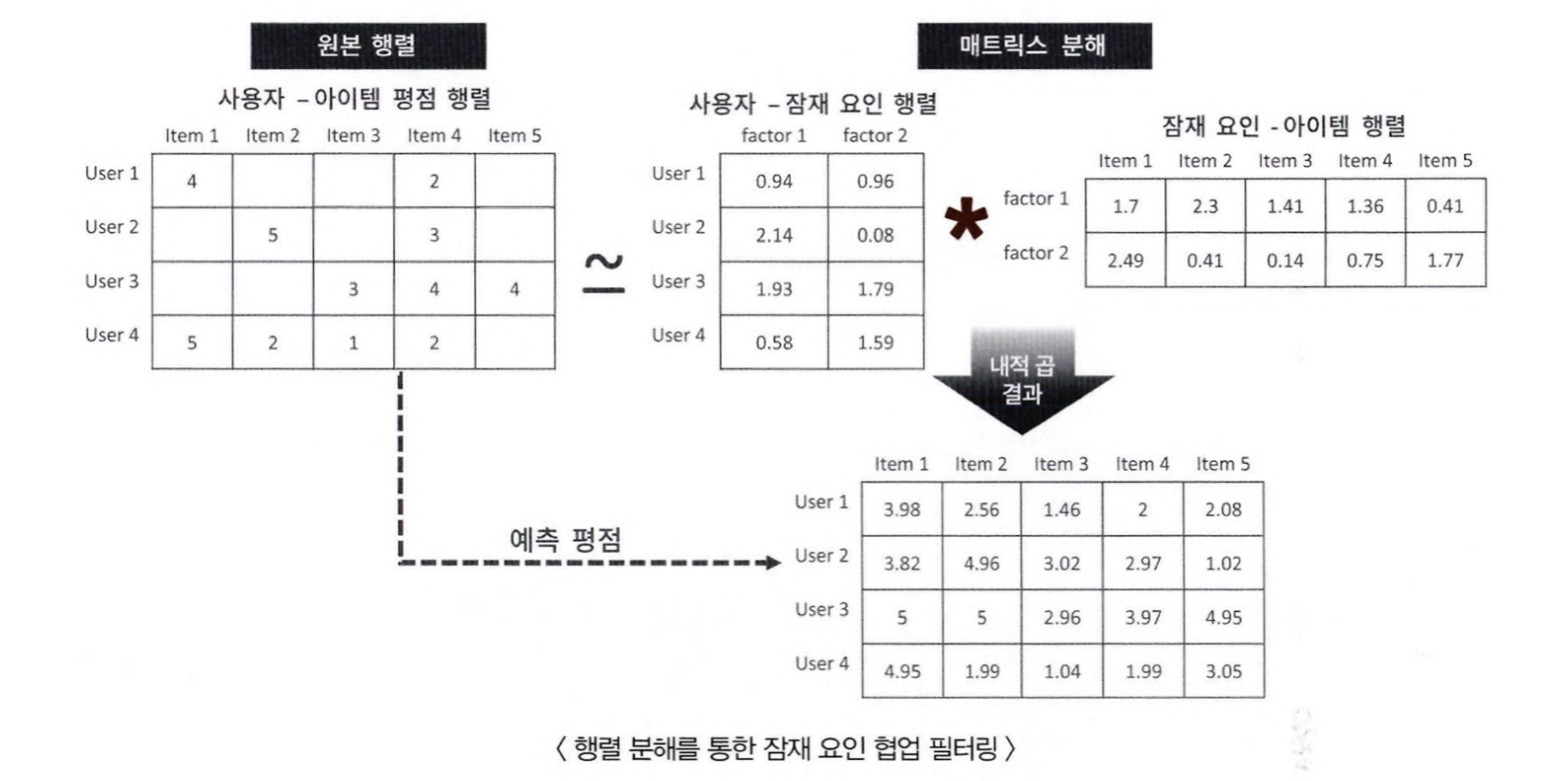




*   행렬 분해에 의해 추출되는 잠재 요인이 정확히 어떤 것인지는 알 수 없지만, 가령 영화 평점 기반의 사용자-아이템 평점 행렬 데이터라면 영화가 가지는 장르별 특성 선호도로 가정할 수 있음. 즉, 사용자-잠재 요인 행렬은 사용자의 영화 장르에 대한 선호도로, 아이템-잠재 요인 행렬은 영화의 장르별 특성 값으로 정의할 수 있음.

다음 그림의 사용자-아이템 평점 행렬 R에서 사용자(User)의 아이템(Item)에 대한 평점을 R(u, i)라고 하면, u는 사용자 아이디, i는 아이템 아이디임. (e.g. R(1,1)은 4점, R(1,4)는 2점임.) 사용자-잠재요인 행렬을 사용자의 영화 장르별 선호도 행렬 P로 가정하고 factor1을 액션(Action) 선호도, factor2를 로맨스(Romance) 선호도로 설정함. (* 설명상 편의를 위해 세상에 영화 장르가 액션과 로맨스밖에 없다고 가정함.) P(u,k)에서 u는 사용자 아이디, k는 잠재 요인 칼럼인 장르별 선호도임. (e.g. 아래의 그림에서 P(1,1)은 0.94, P(1,2)는 0.96임.)
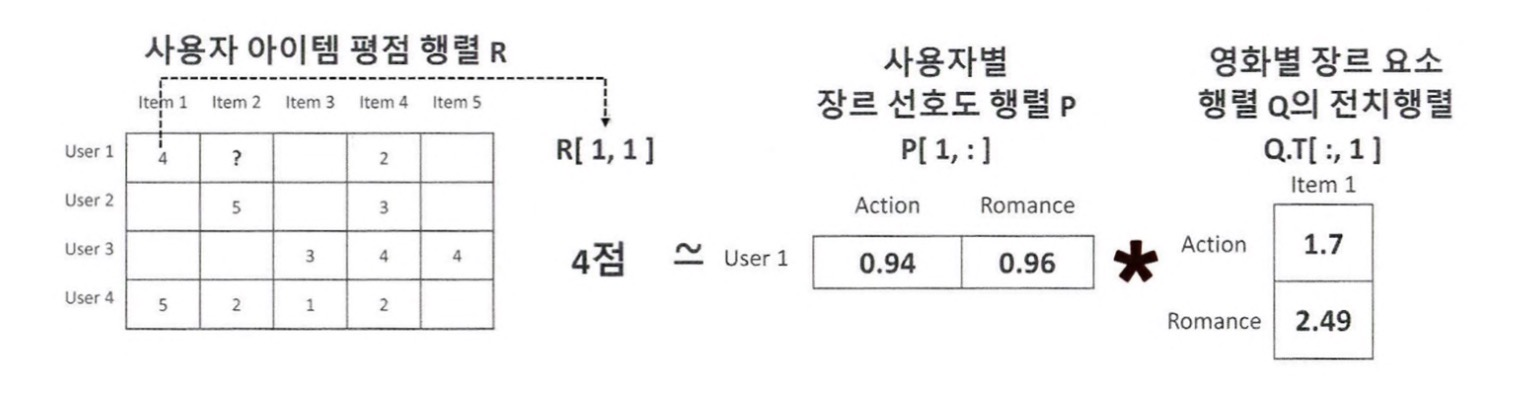



아이템-잠재 요인 행렬은 영화별로 여러 장르 요소로 구성된 영화별 장르별 요소 행렬 Q로 가정하고 factor1은 영화의 Action 요소 값, factor2는 Romance 요소 값임. Q(i, k)에서 i는 아이템 아이디, k는 잠재 요인 칼럼인 장르별 요소임. Q는 P와의 내적 계산을 통해 예측 평점을 계산하기 위해 Q의 행과 열 위치를 교환한 Q.T로 변환함.
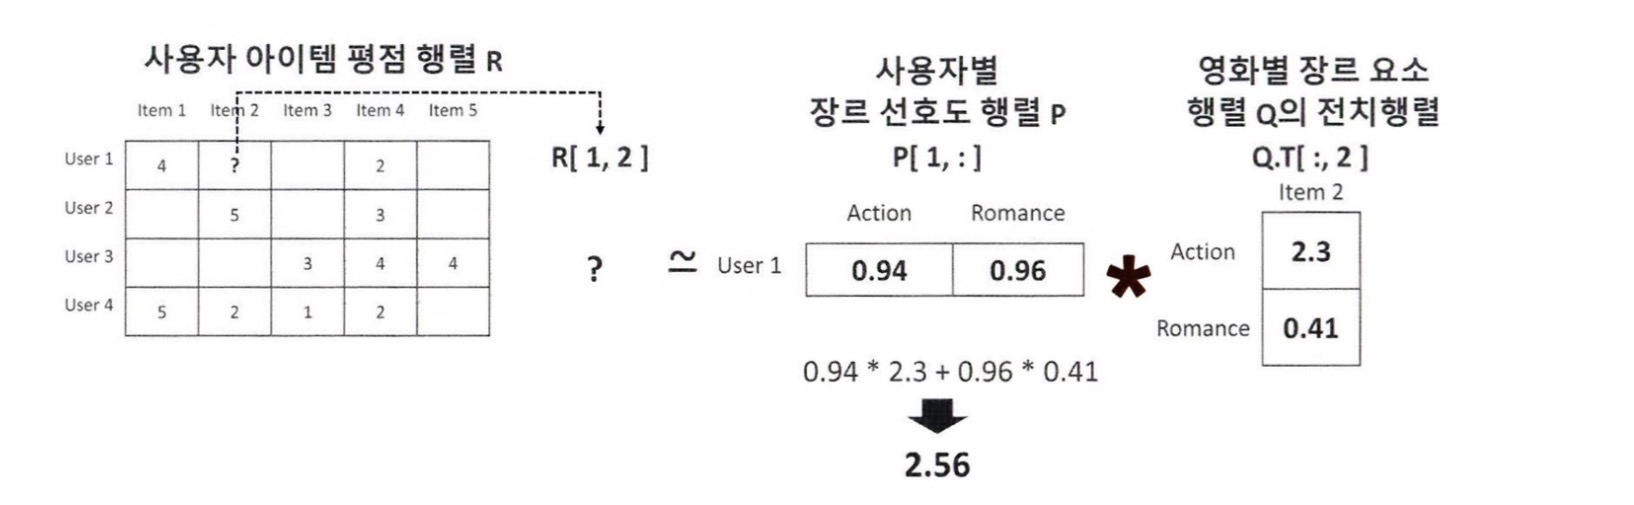

평점이란 사용자의 특정 영화 장르에 대한 선호도와 개별 영화의 그 장르적 특성값을 반영해 결정된다고 생각할 수 있음. (e.g. 사용자가 액션 영화를 매우 좋아하고, 특정 영화가 액션 영화의 특성이 매우 크다면 사용자가 해당 영화에 높은 평점을 줄 것임.) 따라서 평점은 사용자의 장르별 선호도 벡터와 영화의 장르별 특성 벡터를 서로 곱해서 만들 수 있음.

마찬가지 방법으로, 아직 User 1이 평점을 매기지 못한 Item2에 대해 예측 평점을 수행할 수 있음. R(1,2)는 행렬 분해된 P 매트릭스의 User 1 벡터와 Q.T 매트릭스의 Item2 벡터의 내적 결과값인 2.56으로 예측할 수 있음.

### 행렬 분해의 이해


*   행렬 분해는 **다차원의 매트릭스를 저차원 매트릭스로 분해하는 기법**으로서 대표적으로 SVD(Singular Vector Decomposition), NMF(Non-Negative Matrix Factorization) 등이 있음. Factorization(분해)는 우리말로 인수분해를 말함. 행렬 분해도 이와 다르지 않음. 단지 대상이 행렬이라는 것이 다름.
*   M개의 사용자(User) 행과 N개의 아이템(Item) 열을 가진 평점 행렬 R은 M X N 차원으로 구성되며, 행렬 분해를 통해 사용자-K 차원 잠재 요인 행렬 P(P는 M X K 차원)와 K 차원 잠재 요인 - 아이템 행렬 Q.T(Q.T는 K X N 차원)로 분해될 수 있음.



예를 들어, 행렬 내에 NaN 값을 많이 가지는 고차원의 희소 행렬인 R 행렬은 다음 그림과 같이 저차원의 밀집 행렬인 P 행렬과 Q 행렬로 분해될 수 있음. 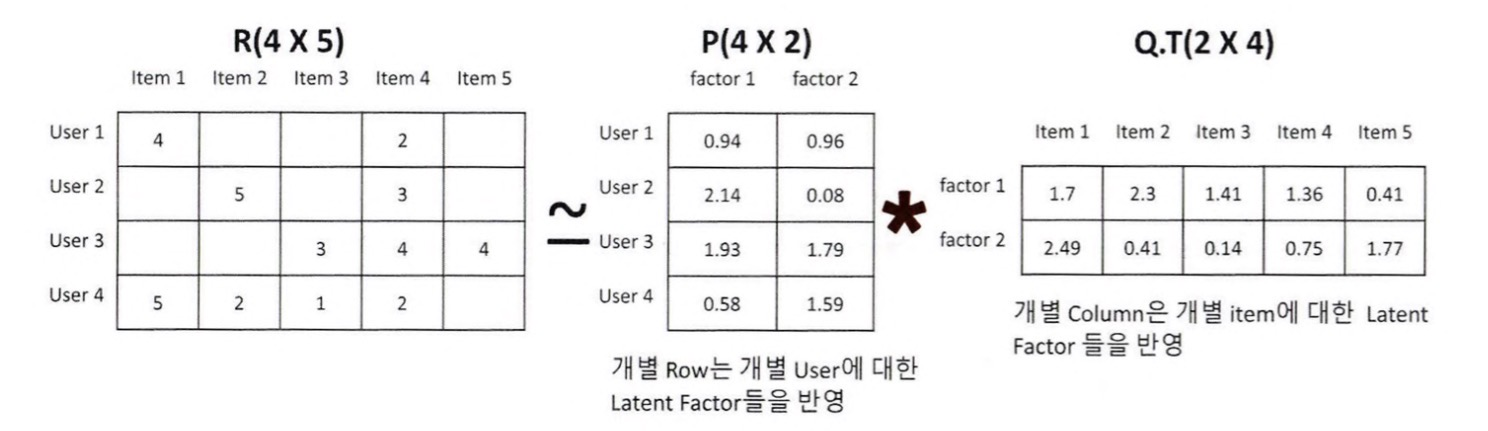

R 행렬의 u행 사용자와 i열 아이템 위치에 있는 평점 데이터를 r(u,i)라고 하면 r(u,i) = p_u * q^t_i임. (* p_는 P행렬에서 u행 사용자의 벡터이며, q^t_i는 Q행렬의 i행 아이템 벡터의 전치 벡터임.)

e.g. r(2,4) 평점 3점은 p_2 * q^t_4이므로 예측값은 2.14 * 1.36 + 0.08 * 0.75 = 2.97로 계산할 수 있음.


사용자가 평가하지 않은 아이템에 대한 평점도 잠재 요인으로 분해된 P 행렬과 Q 행렬을 이용해 예측할 수 있음. R 행렬의 2행 사용자와 3열 아이템에 해당하는 r(2,3)은 아직 사용자가 평점을 매기지 않은 NaN 데이터이나, p_2 * q^t_3 = 2.14 * 1.41 + 0.08 * 0.14 = 3.02로 유추할 수 있음.

*   사용자-아이템 평점 행렬의 미정 값을 포함한 모든 평점 값은 행렬 분해를 통해 얻어진 P 행렬과 Q.T 행렬의 내적을 통해 예측 평점으로 다시 계산할 수 있음. 즉, R ~= P * Q.T임.




*   행렬 분해는 주로 SVD 방식을 이용하나, SVD는 NaN 값이 없는 행렬에만 적용할 수 있음. R 행렬에는 아직 평점이 되지 않은 많은 NaN 값이 있기 때문에 P와 Q 행렬을 일반적인 SVD 방식으로는 분해할 수 없음. 이러한 경우에는 확률적 경사 하강법(Stochastic Gradient Descent, SGD)이나 ALS(Alternating Least Squares) 방식을 이용해 SVD를 수행함.

### 확률적 경사 하강법을 이용한 행렬 분해
*   확률적 경사 하강법을 이용한 행렬 분해 방법을 요약하자면 **P와 Q 행렬로 계산된 예측 R 행렬 값이 실제 R 행렬 값과 가장 최소의 오류를 가질 수 있도록 반복적인 비용 함수 최적화를 통해 P와 Q를 유추**해내는 것임.
*   확률적 경사 하강법을 이용한 행렬 분해의 전반적인 절차는 다음과 같음.
1.   P와 Q를 임의의 값을 가진 행렬로 설정함.
2.   P와 Q.T 값을 곱해 예측 R 행렬을 계산하고 예측 R 행렬과 실제 R 행렬에 해당하는 오류 값을 계산함.
3. 이 오류 값을 최소화할 수 있도록 P와 Q 행렬을 적절한 값으로 각각 업데이트함.
4. 만족할 만한 오류 값을 가질 때까지 2, 3번 작업을 반복하면서 P와 Q 값을 업데이트해 근사화함.
*   실제 값과 예측값의 오류 최소화와 L2 규제(regulation)를 고려한 비용 함수식은 다음과 같음.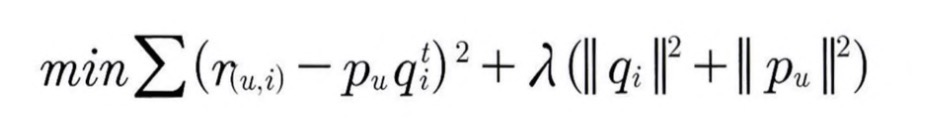







*   일반적으로 사용자-아이템 평점 행렬의 경우 행렬 분해를 위해 단순히 예측 오류값의 최소화와 학습 시 과적합을 피하기 위해 규제를 반영한 비용 함수를 적용함. 그리고 위의 비용 함수를 최소화하기 위해 새롭게 식을 업데이트하면 다음과 같음.
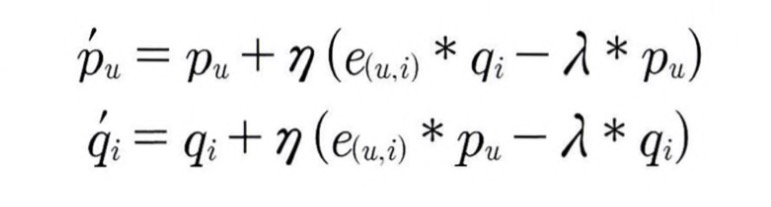



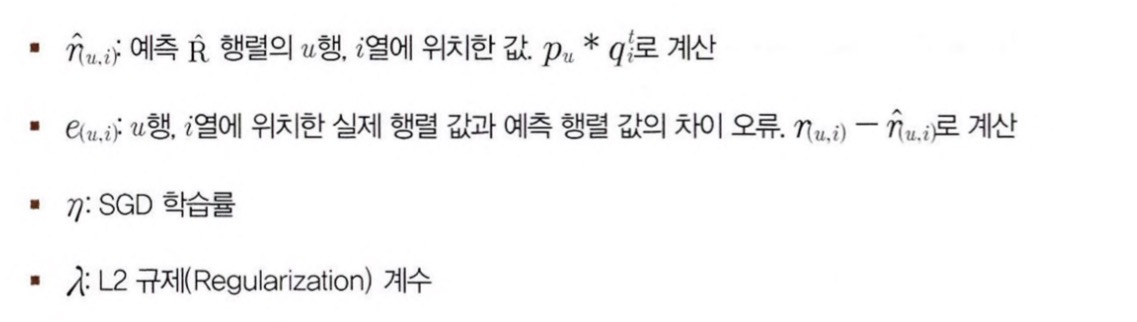



*   경사 하강법을 이용한 회귀는 비용 함수를 최소화하는 방향성을 가지고 회귀 계수의 업데이트 값(w1_update, w0_update)을 구하고 이 업데이트 값을 회귀 계수에 반복적으로 적용하는 것이 핵심 로직이었음. 평점 행렬을 경사 하강법을 이용해 행렬 분해하는 것도 이와 유사함. **L2 규제를 반영해 실제 R 행렬 값과 예측 R 행렬 값의 차이를 최소화하는 방향성을 가지고 P행렬과 Q행렬에 업데이트 값을 반복적으로 수행하면서 최적화된 예측 R행렬을 구하는 방식**이 **SGD 기반의 행렬 분해**임.



In [2]:
# SGD를 이용해 행렬 분해를 수행하는 예제

import numpy as np

R = np.array([[4, np.nan, np.nan, 2, np.nan],
              [np.nan, 5, np.nan, 3, 1],
              [np.nan, np.nan, 3, 4, 4],
              [5, 2, 1, 2, np.nan]])
num_users, num_items = R.shape
K=3   ## 잠재 요인 차원은 3으로 설정

np.random.seed(1)
P = np.random.normal(scale=1./K, size=(num_users, K))   ## 분해 행렬 P와 Q는 정규 분포를 가진 랜덤 값으로 초기화
Q = np.random.normal(scale=1./K, size=(num_items, K))

In [3]:
# 실제 R 행렬과 예측 행렬의 오차를 구하는 함수 만들기

from sklearn.metrics import mean_squared_error

def get_rmse(R, P, Q, non_zeros):
  error = 0
  full_pred_matrix = np.dot(P, Q.T)    ## 두 개의 분해된 행렬 P와 Q.T의 내적으로 예측 R 행렬 생성

  x_non_zero_ind = [non_zero[0] for non_zero in non_zeros]
  y_non_zero_ind = [non_zero[1] for non_zero in non_zeros]
  R_non_zeros = R[x_non_zero_ind, y_non_zero_ind]
  full_pred_matrix_non_zeros = full_pred_matrix[x_non_zero_ind, y_non_zero_ind]
  mse = mean_squared_error(R_non_zeros, full_pred_matrix_non_zeros)
  rmse = np.sqrt(mse)

## get_rmse() 함수는 실제 R 행렬의 널이 아닌 행렬 값의 위치 인덱스를 추출해, 이 인덱스에 있는 실제 R 행렬 값과 분해된 P, Q를 이용해 다시 조합된 예측 행렬 값의 RMSE 값을 반환함

In [4]:
non_zeros = [ (i, j, R[i, j]) for i in range(num_users) for j in range(num_items) if R[i, j] > 0]

steps = 1000   ## steps는 SGD를 반복해서 업데이트할 횟수
learning_rate = 0.01   ## learning_rate는 SGD의 학습률
r_lambda = 0.01    ## r_lambda는 L2 Regularization 계수

for step in range(steps):
  for i, j, r in non_zeros:
    eij = r - np.dot(P[i, :], Q[j, :].T)

    P[i, :] = P[i, :] + learning_rate*(eij * Q[j, :] - r_lambda*P[i, :])
    Q[j, :] = Q[j, :] + learning_rate*(eij * P[i, :] - r_lambda*Q[j, :])

    rmse = get_rmse(R, P, Q, non_zeros)
    if (step % 50) == 0 :
      print("iteration step: ", step, "rmse: ", rmse)

iteration step:  0 rmse:  None
iteration step:  0 rmse:  None
iteration step:  0 rmse:  None
iteration step:  0 rmse:  None
iteration step:  0 rmse:  None
iteration step:  0 rmse:  None
iteration step:  0 rmse:  None
iteration step:  0 rmse:  None
iteration step:  0 rmse:  None
iteration step:  0 rmse:  None
iteration step:  0 rmse:  None
iteration step:  0 rmse:  None
iteration step:  50 rmse:  None
iteration step:  50 rmse:  None
iteration step:  50 rmse:  None
iteration step:  50 rmse:  None
iteration step:  50 rmse:  None
iteration step:  50 rmse:  None
iteration step:  50 rmse:  None
iteration step:  50 rmse:  None
iteration step:  50 rmse:  None
iteration step:  50 rmse:  None
iteration step:  50 rmse:  None
iteration step:  50 rmse:  None
iteration step:  100 rmse:  None
iteration step:  100 rmse:  None
iteration step:  100 rmse:  None
iteration step:  100 rmse:  None
iteration step:  100 rmse:  None
iteration step:  100 rmse:  None
iteration step:  100 rmse:  None
iteration ste

In [5]:
pred_matrix = np.dot(P, Q.T)
print('예측 행렬: \n', np.round(pred_matrix, 3))

예측 행렬: 
 [[3.991 0.897 1.306 2.002 1.663]
 [6.696 4.978 0.979 2.981 1.003]
 [6.677 0.391 2.987 3.977 3.986]
 [4.968 2.005 1.006 2.017 1.14 ]]


원본 행렬과 비교해 널이 아닌 값은 큰 차이가 나지 않으며, 널인 값은 새로운 예측값으로 채워짐.